<a href="https://colab.research.google.com/github/KeylaAH/KeylaAH/blob/main/Classification_Model_KAH_version_4_just_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Setup of all libraries needed and uploading the data
# ────────────────import and inspect ────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
train_test_split, GridSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


data = pd.read_csv("train.csv")

print(f"Visualize Data:")
print(data.head(3))


Visualize Data:
  household_id  num_occupants  home_size_m2  home_age_years  \
0       HH0852            2.0         211.6            47.0   
1       HH1260            6.0          86.2            18.0   
2       HH1955            6.0         159.9             9.0   

   avg_outdoor_temp_c  num_appliances  num_smart_devices  solar_panel_kw  \
0                14.0            19.0                4.0            2.63   
1                10.9            10.0                1.0            2.36   
2                14.4            12.0                9.0            0.18   

   insulation_rating  has_ev_charger  has_pool consumption_profile  
0                3.0             0.0       0.0                 Low  
1                3.0             1.0       0.0                High  
2                4.0             0.0       0.0                High  


In [3]:
#print(data.head())
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   household_id         1600 non-null   object 
 1   num_occupants        1600 non-null   float64
 2   home_size_m2         1600 non-null   float64
 3   home_age_years       1600 non-null   float64
 4   avg_outdoor_temp_c   1600 non-null   float64
 5   num_appliances       1600 non-null   float64
 6   num_smart_devices    1600 non-null   float64
 7   solar_panel_kw       1600 non-null   float64
 8   insulation_rating    1600 non-null   float64
 9   has_ev_charger       1600 non-null   float64
 10  has_pool             1600 non-null   float64
 11  consumption_profile  1600 non-null   object 
dtypes: float64(10), object(2)
memory usage: 150.1+ KB
None
       num_occupants  home_size_m2  home_age_years  avg_outdoor_temp_c  \
count    1600.000000   1600.000000     1600.000000         

In [4]:
# storing househols_id away before runing the model
HH_id = data["household_id"]
#print (HH_id)

In [5]:
#Converting categorical column into integers for usage
data["consumption_profile"] = data["consumption_profile"].map({"Minimal": 0, "Low": 1, "Moderate": 2, "High": 3, "Heavy": 4})

In [6]:
# I have already save my id so I will drop it to analyze data
data = data.drop("household_id", axis = 1)

#converting everything to numeric jsut to be safe
data = data.apply(pd.to_numeric, errors ='coerce')



In [8]:
print(data.head(2))
print(data.info())
print(data.describe())

   num_occupants  home_size_m2  home_age_years  avg_outdoor_temp_c  \
0            2.0         211.6            47.0                14.0   
1            6.0          86.2            18.0                10.9   

   num_appliances  num_smart_devices  solar_panel_kw  insulation_rating  \
0            19.0                4.0            2.63                3.0   
1            10.0                1.0            2.36                3.0   

   has_ev_charger  has_pool  consumption_profile  
0             0.0       0.0                    1  
1             1.0       0.0                    3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   num_occupants        1600 non-null   float64
 1   home_size_m2         1600 non-null   float64
 2   home_age_years       1600 non-null   float64
 3   avg_outdoor_temp_c   1600 non-null   float64
 4 

In [10]:
# Now that we have all integers in our data we can check for missing values etc..
#Check the data for missing nan values in order to choose features:
#print(data.head(4))
#print("")
print(f"missing values:")
print(data.isna().sum())      # check missing values
print("")
print(f"NaN values:")
print(np.isnan(data).sum())   # count NaNs
print("")
print(f"inf values:")
print(np.isinf(data).sum())   # count infs
print(f"Shape of Data points:")
print(data.shape)

missing values:
num_occupants          0
home_size_m2           0
home_age_years         0
avg_outdoor_temp_c     0
num_appliances         0
num_smart_devices      0
solar_panel_kw         0
insulation_rating      0
has_ev_charger         0
has_pool               0
consumption_profile    0
dtype: int64

NaN values:
num_occupants          0
home_size_m2           0
home_age_years         0
avg_outdoor_temp_c     0
num_appliances         0
num_smart_devices      0
solar_panel_kw         0
insulation_rating      0
has_ev_charger         0
has_pool               0
consumption_profile    0
dtype: int64

inf values:
num_occupants          0
home_size_m2           0
home_age_years         0
avg_outdoor_temp_c     0
num_appliances         0
num_smart_devices      0
solar_panel_kw         0
insulation_rating      0
has_ev_charger         0
has_pool               0
consumption_profile    0
dtype: int64
Shape of Data points:
(1600, 11)


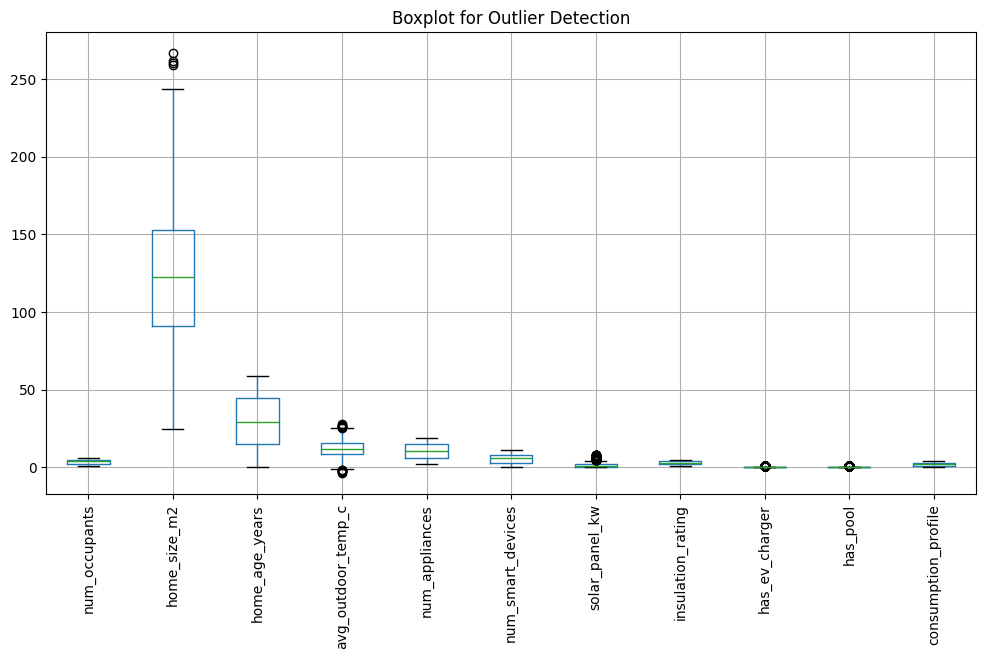

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming X is a DataFrame
data_df = pd.DataFrame(data)

plt.figure(figsize=(12,6))
data_df.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [12]:
import numpy as np

Q1 = data_df.quantile(0.25)
Q3 = data_df.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = ((data_df < lower_bound) | (data_df > upper_bound))

# Count outliers per column
outlier_counts = outliers.sum()

print("Outliers per feature:\n")
print(outlier_counts)

# Total rows with any outlier
rows_with_outliers = outliers.any(axis=1).sum()
print(f"\nTotal rows with outliers: {rows_with_outliers}")

Outliers per feature:

num_occupants            0
home_size_m2             4
home_age_years           0
avg_outdoor_temp_c      15
num_appliances           0
num_smart_devices        0
solar_panel_kw          81
insulation_rating        0
has_ev_charger         259
has_pool               172
consumption_profile      0
dtype: int64

Total rows with outliers: 468


In [13]:
# Select the column
col = 'home_size_m2'

# Compute IQR
Q1 = data_df[col].quantile(0.25)
Q3 = data_df[col].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset (keep only non-outliers)
X_clean = data_df[(data_df[col] >= lower_bound) & (data_df[col] <= upper_bound)]

# IMPORTANT: also filter target variable
#y_clean = y.loc[X_clean.index]

print(f"Original rows: {data_df.shape[0]}")
print(f"Rows after removing home_size outliers: {X_clean.shape[0]}")

print(f"X shape: {X_clean.shape}")
#print(f"y shape: {y_clean.shape}")

Original rows: 1600
Rows after removing home_size outliers: 1596
X shape: (1596, 11)


In [14]:
outliers_removed = data_df[(data_df[col] < lower_bound) | (data_df[col] > upper_bound)]

print("Removed rows:\n")
print(outliers_removed)

Removed rows:

     num_occupants  home_size_m2  home_age_years  avg_outdoor_temp_c  \
445            2.0         266.7            54.0                 7.5   
763            6.0         260.5            47.0                 6.1   
873            5.0         259.2            19.0                 2.1   
942            4.0         261.4            40.0                19.4   

     num_appliances  num_smart_devices  solar_panel_kw  insulation_rating  \
445            16.0                1.0            0.04                2.0   
763            15.0                4.0            0.39                3.0   
873             8.0                0.0            0.04                5.0   
942             9.0               11.0            1.60                3.0   

     has_ev_charger  has_pool  consumption_profile  
445             0.0       0.0                    4  
763             0.0       0.0                    4  
873             1.0       0.0                    4  
942             1.0       

In [15]:
#removing outliers and checking the right amount were removed

selected_features = [
    "num_occupants", "home_size_m2", "home_age_years",
    "avg_outdoor_temp_c", "num_appliances", "num_smart_devices",
    "solar_panel_kw", "insulation_rating", "has_ev_charger", "has_pool"
]

X = data[selected_features]
y = data["consumption_profile"]

print("Original shape:", X.shape)
print(y.value_counts())

outlier_cols = ["home_size_m2", "avg_outdoor_temp_c", "solar_panel_kw"]
mask = pd.Series(True, index=X.index)

for col in outlier_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = mask & (X[col] >= lower_bound) & (X[col] <= upper_bound)

X = X[mask]
y = y.loc[X.index]   # align to the freshly filtered X

print("\nAfter removing outliers:")
print("X shape:", X.shape)
print(y.value_counts())

Original shape: (1600, 10)
consumption_profile
2    549
3    398
1    319
0    170
4    164
Name: count, dtype: int64

After removing outliers:
X shape: (1502, 10)
consumption_profile
2    529
3    387
1    298
4    154
0    134
Name: count, dtype: int64


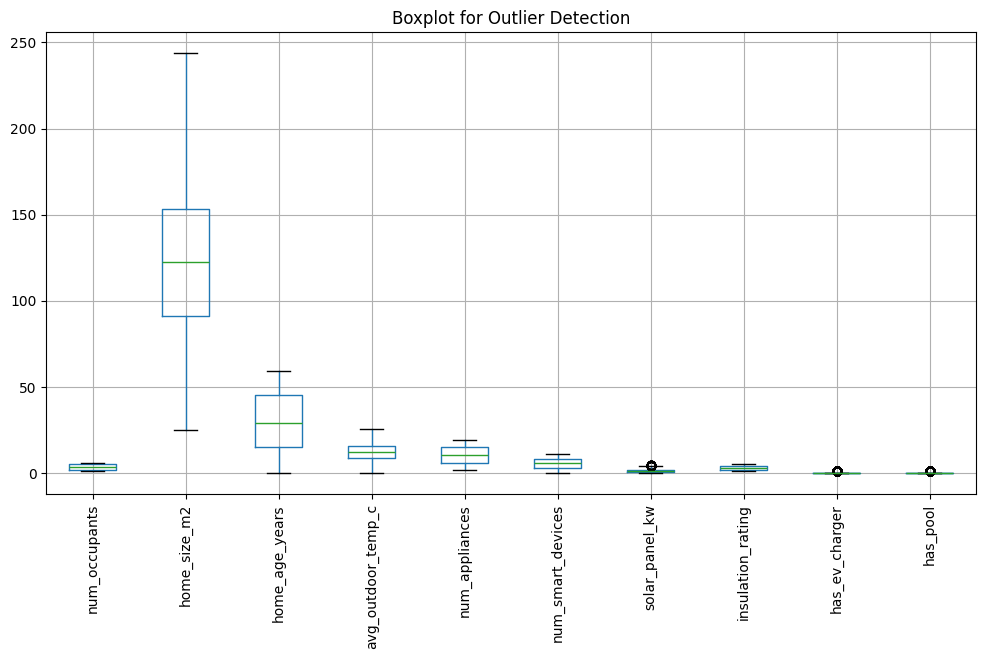

In [16]:
#grahing the outliers again
import matplotlib.pyplot as plt
import pandas as pd


# Assuming X is a DataFrame
X_df = pd.DataFrame(X)

plt.figure(figsize=(12,6))
X_df.boxplot(rot=90)
plt.title("Boxplot for Outlier Detection")
plt.show()
#print("X Shape:", X)

In [17]:
#Loading Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import LabelEncoder




In [18]:
#Additional libraries
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Model
from sklearn.svm import SVC


# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Pipeline

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),              # will be tuned
    ('feature_select', SelectKBest(score_func=f_classif)),  # new
    ('clf', SVC(probability=True))
])


# Parameter Distribution

param_dist = {

    'scaler': [StandardScaler()],

    'clf__C': [5, 10, 20],
    'clf__gamma': [0.005, 0.01, 0.02, 0.03],
    'clf__kernel': ['rbf'],

    # both options
    'clf__class_weight': [None, 'balanced']
}

# Randomized Search

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
   scoring='accuracy',     # balanced performance
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)


# Train Model

print("\n Training Optimized SVM...\n") #Checking it has gotten this far
search.fit(X_train, y_train)


# Best Model

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)


# Evaluation

print("\n===== FINAL MODEL RESULTS =====")
print(f"Best Params: {search.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Training Optimized SVM...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

===== FINAL MODEL RESULTS =====
Best Params: {'scaler': StandardScaler(), 'clf__kernel': 'rbf', 'clf__gamma': 0.02, 'clf__class_weight': None, 'clf__C': 20}
Accuracy: 0.7508
F1 Macro: 0.7169

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.48      0.59        27
           1       0.71      0.78      0.75        60
           2       0.76      0.82      0.79       106
           3       0.76      0.78      0.77        77
           4       0.79      0.61      0.69        31

    accuracy                           0.75       301
   macro avg       0.76      0.70      0.72       301
weighted avg       0.75      0.75      0.75       301


Confusion Matrix:
 [[13 10  2  1  1]
 [ 1 47 11  1  0]
 [ 2  7 87  9  1]
 [ 1  1 12 60  3]
 [ 0  1  3  8 19]]


In [20]:
import pandas as pd


# Load test file

test_df = pd.read_csv("test.csv")
print("Test shape:", test_df.shape)
print(test_df.head())
print(test_df.info())


# Extract household_id

household_id = test_df["household_id"]


# Prepare features (drop household_id)

X_test_final = test_df[selected_features]

print("\nTest features shape:", X_test_final.shape)
print(X_test_final.isnull().sum())  # check for missing values


# Run predictions

predicted_profile = best_model.predict(X_test_final)

#convert back to words
predicted_profile_words = pd.Series(predicted_profile).map({
    0: "Minimal",
    1: "Low",
    2: "Moderate",
    3: "High",
    4: "Heavy"

}).values


# building submission DataFrame

submission = pd.DataFrame({
    "household_id": household_id,
    "predicted_profile": predicted_profile_words
})



print("\nSubmission preview:")
print(submission.head(10))
print("\nPredicted class distribution:")
print(submission["predicted_profile"].value_counts())


# Save to CSV

submission.to_csv("submission.csv", index=False)
print("\n submission.csv saved successfully!")

Test shape: (400, 11)
  household_id  num_occupants  home_size_m2  home_age_years  \
0       HH1351            5.0         153.4             7.0   
1       HH1240            3.0          25.0            24.0   
2       HH0980            4.0         146.3            46.0   
3       HH0496            4.0         108.5            13.0   
4       HH0398            2.0          25.0            43.0   

   avg_outdoor_temp_c  num_appliances  num_smart_devices  solar_panel_kw  \
0                 4.2            13.0               10.0            0.22   
1                11.9             4.0                6.0            2.78   
2                22.5            13.0                2.0            1.27   
3                14.8            17.0                4.0            0.36   
4                13.8            18.0                6.0            2.11   

   insulation_rating  has_ev_charger  has_pool  
0                2.0             1.0       0.0  
1                4.0             0.0       0

In [21]:
#This part of the code was copied to compare results between SVM AND AdaBoost
# Core
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Models
models = {
    "SVM": SVC(probability=True)

    #"AdaBoost": AdaBoostClassifier(
    #    random_state=42
    #)
}

# Parameter Grids
param_grids = {

    "SVM": {
        #'clf__C': [0.5, 1, 10, 50],
        #'clf__gamma': ['scale', 0.01, 0.02],
        #'clf__class_weight': ['balanced']

        'clf__C': [0.1, 1, 5, 10, 50, 100],
        'clf__gamma': [0.005, 0.01, 0.02, 0.03, 'scale'],
        'clf__kernel': ['rbf'],
        #'clf__degree': [2, 3],  # only used if kernel='poly'
        'clf__class_weight': [None, 'balanced']

    }#,

    #"AdaBoost": {
    #    'clf__n_estimators': [50, 100, 200],
    #    'clf__learning_rate': [0.01, 0.05, 0.1, 1.0]
    #}
}

# Run Models
results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...\n")

    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        #('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=20,
        scoring='f1_macro',
        cv=10,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"Best Params: {search.best_params_}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results[name] = acc

# Summary
print("\n===== Model Comparison:======")
for model, score in results.items():
    print(f"{model}: {score:.4f}")


🔹 Training SVM...

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best Params: {'clf__kernel': 'rbf', 'clf__gamma': 0.03, 'clf__class_weight': None, 'clf__C': 10}
Accuracy: 0.7475

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.48      0.59        27
           1       0.71      0.78      0.75        60
           2       0.75      0.82      0.78       106
           3       0.76      0.77      0.76        77
           4       0.79      0.61      0.69        31

    accuracy                           0.75       301
   macro avg       0.75      0.69      0.71       301
weighted avg       0.75      0.75      0.74       301


Confusion Matrix:
 [[13 10  2  1  1]
 [ 1 47 11  1  0]
 [ 2  7 87  9  1]
 [ 1  1 13 59  3]
 [ 0  1  3  8 19]]

===== Model Comparison:======
SVM: 0.7475
